# Load DIV30 and DIV90 Raw 10x Samples to AnnData

This notebook defines a small in-notebook builder class for raw 10x sample loading. The immediate focus is DIV30, but the same object works for DIV90 or both time points by changing `target_divs`.

The builder reads per-sample 10x matrices from `metadata/div30_div90_sample_id_to_biolabel_map.tsv`, adds sample metadata to `.obs`, makes cell IDs unique by prefixing the 10x barcode with `run_sample_id`, and can return either a per-sample AnnData list or a combined AnnData object.


In [1]:
import os
from dataclasses import dataclass
from pathlib import Path
from typing import Optional, Sequence

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.stats import median_abs_deviation as mad

In [5]:
@dataclass
class Raw10xAnnDataBuilder:
    """Minimal teaching builder: only methods used in this tutorial."""

    project_root: Path
    target_divs: Sequence[str] = ("DIV30",)
    target_run_sample_ids: Optional[Sequence[str]] = None
    sample_map_name: str = "metadata/div30_div90_sample_id_to_biolabel_map.tsv"
    matrix_source: str = "filtered"
    strict_missing_matrix_dirs: bool = True

    @property
    def sample_map_tsv(self) -> Path:
        """Compute sample map path only (no file read)."""
        return self.project_root / self.sample_map_name

    def _normalize_matrix_source(self, matrix_source: str) -> str:
        normalized = str(matrix_source).strip().lower()
        valid_sources = {"raw", "filtered", "auto"}
        if normalized not in valid_sources:
            raise ValueError(
                f"matrix_source must be one of {sorted(valid_sources)}; got: {matrix_source!r}"
            )
        return normalized

    def _resolve_matrix_dir(self, per_sample_metrics_csv: str, matrix_source: str = None) -> Path:
        """Resolve matrix directory with explicit raw/filtered/auto preference."""
        count_dir = Path(per_sample_metrics_csv).parent / "count"
        resolved_source = self._normalize_matrix_source(matrix_source or self.matrix_source)

        raw_candidates = [
            count_dir / "sample_raw_feature_bc_matrix",
            count_dir / "raw_feature_bc_matrix",
        ]
        filtered_candidates = [
            count_dir / "sample_filtered_feature_bc_matrix",
            count_dir / "filtered_feature_bc_matrix",
        ]

        if resolved_source == "raw":
            candidates = raw_candidates + filtered_candidates
        elif resolved_source == "filtered":
            candidates = filtered_candidates + raw_candidates
        else:
            candidates = raw_candidates + filtered_candidates

        for candidate in candidates:
            if candidate.exists():
                return candidate

        # Return source-preferred path so downstream missing-dir errors are explicit.
        return candidates[0]

    def sample_table(self, matrix_source: str = None, matrix_dir_overrides: Optional[dict] = None) -> pd.DataFrame:
        """Read/filter sample metadata and derive matrix paths with optional per-sample overrides."""
        resolved_source = self._normalize_matrix_source(matrix_source or self.matrix_source)
        sample_metadata_df = pd.read_csv(self.sample_map_tsv, sep="\t")
        required = {"DIV", "run_sample_id", "biological_label", "per_sample_metrics_csv"}
        missing = required.difference(sample_metadata_df.columns)
        if missing:
            raise ValueError(f"Sample map is missing required columns: {sorted(missing)}")

        sample_metadata_df = sample_metadata_df[sample_metadata_df["DIV"].isin(self.target_divs)].copy()

        if self.target_run_sample_ids is not None:
            sample_metadata_df = sample_metadata_df[
                sample_metadata_df["run_sample_id"].isin(self.target_run_sample_ids)
            ].copy()
            found = set(sample_metadata_df["run_sample_id"].astype(str))
            missing_ids = [sid for sid in self.target_run_sample_ids if sid not in found]
            if missing_ids:
                raise ValueError(f"Missing requested run_sample_id values in sample map: {missing_ids}")

        if sample_metadata_df.empty:
            raise ValueError("No samples matched target_divs/target_run_sample_ids.")

        # Normalize replicate-level labels (e.g., H9_rep1) to canonical cell lines (H9/79B/2E).
        sample_metadata_df["cell_line"] = sample_metadata_df["biological_label"].astype("string").str.extract(
            r"^(H9|79B|2E)",
            expand=False,
        )

        invalid_rows = sample_metadata_df[sample_metadata_df["cell_line"].isna()][["run_sample_id", "biological_label"]]
        if not invalid_rows.empty:
            examples = invalid_rows.head(10).to_dict(orient="records")
            raise ValueError(
                "Could not map some biological_label values to expected cell_line prefixes "
                "(H9, 79B, 2E). Examples: "
                f"{examples}"
            )

        sample_metadata_df["DIV"] = pd.Categorical(sample_metadata_df["DIV"], categories=self.target_divs, ordered=True)
        if self.target_run_sample_ids is not None:
            sample_metadata_df["run_sample_id"] = pd.Categorical(
                sample_metadata_df["run_sample_id"],
                categories=self.target_run_sample_ids,
                ordered=True,
            )

        sample_metadata_df = sample_metadata_df.sort_values(["DIV", "run_sample_id"]).reset_index(drop=True)
        sample_metadata_df["run_sample_id_str"] = sample_metadata_df["run_sample_id"].astype(str)
        sample_metadata_df["matrix_dir"] = sample_metadata_df["per_sample_metrics_csv"].map(
            lambda p: str(self._resolve_matrix_dir(p, matrix_source=resolved_source))
        )
        sample_metadata_df["matrix_source"] = resolved_source

        # Optional external overrides let you point run_sample_id values to CellBender or other paths.
        if matrix_dir_overrides:
            override_map = {str(k): str(v) for k, v in matrix_dir_overrides.items()}
            override_mask = sample_metadata_df["run_sample_id_str"].isin(override_map.keys())
            sample_metadata_df.loc[override_mask, "matrix_dir"] = sample_metadata_df.loc[override_mask, "run_sample_id_str"].map(override_map)
            sample_metadata_df.loc[override_mask, "matrix_source"] = "external"

        return sample_metadata_df[["DIV", "run_sample_id", "cell_line", "matrix_dir", "matrix_source"]]

    def _load_component_adatas(self, matrix_source: str = None, matrix_dir_overrides: Optional[dict] = None):
        """Load per-sample AnnData objects and return a dict keyed by run_sample_id."""
        sample_metadata_df = self.sample_table(
            matrix_source=matrix_source,
            matrix_dir_overrides=matrix_dir_overrides,
        )
        sample_adatas_by_run = {}
        missing_dirs = []

        for _, row in sample_metadata_df.iterrows():
            matrix_dir = Path(row["matrix_dir"])
            if not matrix_dir.exists():
                missing_dirs.append(str(matrix_dir))
                continue

            one_sample_adata = sc.read_10x_mtx(matrix_dir, var_names="gene_symbols", make_unique=True)
            run_sample_id = str(row["run_sample_id"])

            one_sample_adata.obs_names = [f"{run_sample_id}:{barcode}" for barcode in one_sample_adata.obs_names]
            one_sample_adata.obs["DIV"] = str(row["DIV"])
            one_sample_adata.obs["run_sample_id"] = run_sample_id
            one_sample_adata.obs["cell_line"] = str(row["cell_line"])
            one_sample_adata.obs["matrix_dir"] = str(matrix_dir)
            one_sample_adata.obs["matrix_source"] = str(row["matrix_source"])
            sample_adatas_by_run[run_sample_id] = one_sample_adata

        if missing_dirs:
            message = "Missing per-sample 10x matrix directories:\n" + "\n".join(f" - {p}" for p in missing_dirs)
            if self.strict_missing_matrix_dirs:
                raise FileNotFoundError(message)
            print(message)

        if not sample_adatas_by_run:
            raise FileNotFoundError("No per-sample 10x matrix directories were found.")

        return sample_metadata_df, sample_adatas_by_run

    def per_sample_anndata_list(self, matrix_source: str = None, matrix_dir_overrides: Optional[dict] = None):
        """Return per-sample AnnData objects as an ordered list plus matching run_sample_id names."""
        sample_metadata_df, sample_adatas_by_run = self._load_component_adatas(
            matrix_source=matrix_source,
            matrix_dir_overrides=matrix_dir_overrides,
        )
        adata_names = sample_metadata_df["run_sample_id"].astype(str).tolist()
        adata_list = [sample_adatas_by_run[run_sample_id] for run_sample_id in adata_names]
        return adata_names, adata_list

    def _finalize_combined(self, combined_adata: ad.AnnData, sample_metadata_df: pd.DataFrame) -> ad.AnnData:
        """Apply common post-concatenation typing, checks, and provenance fields."""
        if not combined_adata.obs_names.is_unique:
            duplicated = combined_adata.obs_names[combined_adata.obs_names.duplicated()].unique()[:10].tolist()
            raise ValueError(f"Combined AnnData has duplicated obs_names. Examples: {duplicated}")

        combined_adata.obs["DIV"] = pd.Categorical(combined_adata.obs["DIV"], categories=self.target_divs, ordered=True)
        combined_adata.obs["run_sample_id"] = pd.Categorical(
            combined_adata.obs["run_sample_id"],
            categories=sample_metadata_df["run_sample_id"].astype(str).tolist(),
            ordered=True,
        )
        combined_adata.obs["cell_line"] = combined_adata.obs["cell_line"].astype("string")
        combined_adata.obs["matrix_dir"] = combined_adata.obs["matrix_dir"].astype("string")
        if "matrix_source" in combined_adata.obs.columns:
            combined_adata.obs["matrix_source"] = combined_adata.obs["matrix_source"].astype("string")

        combined_adata.uns["sample_map_tsv"] = str(self.sample_map_tsv)
        combined_adata.uns["target_divs"] = list(self.target_divs)
        if "matrix_source" in sample_metadata_df.columns:
            combined_adata.uns["matrix_source"] = str(sample_metadata_df["matrix_source"].iloc[0])
        combined_adata.uns["combine_logic"] = (
            "Per-sample 10x matrices were read separately, annotated, barcode-prefixed by "
            "run_sample_id, and concatenated along observations with an outer gene join."
        )
        return combined_adata

    def combined_anndata_concat(
        self,
        join: str = "outer",
        label: str = "batch",
        matrix_source: str = None,
        matrix_dir_overrides: Optional[dict] = None,
    ) -> ad.AnnData:
        """Alternative combine path using anndata.concat with a batch key in .obs."""
        sample_metadata_df, sample_adatas_by_run = self._load_component_adatas(
            matrix_source=matrix_source,
            matrix_dir_overrides=matrix_dir_overrides,
        )
        combined_adata = ad.concat(
            sample_adatas_by_run,
            axis=0,
            join=join,
            merge="same",
            fill_value=0,
            index_unique=None,
            label=label,
        )

        # Ensure batch values are run_sample_id values, and keep run_sample_id explicit.
        if label in combined_adata.obs.columns:
            combined_adata.obs[label] = combined_adata.obs[label].astype("string")
            combined_adata.obs["run_sample_id"] = combined_adata.obs[label].astype("string")

        return self._finalize_combined(combined_adata, sample_metadata_df)

## Builder Instantiation Tutorial (Minimal Method Version)

This notebook now uses a simplified class that keeps only the methods needed for your learning path:

1. `sample_map_tsv` (property)
2. `sample_table()`
3. `per_sample_anndata_list()`
4. `combined_anndata_concat()`

Methods like `read_one_sample`, `component_anndatas`, `cell_count_tables`, and `anndata_set` were intentionally removed for clarity. Their logic is now either unnecessary for this tutorial or inlined.

### Seurat vs Scanpy data storage model

Here comes another difference from Seurat. The R package stores raw data, scaled data and variable genes information in separate slots, Scanpy instead keeps only one snapshot of the data.

In practice with AnnData, this means:

- active matrix is typically in `.X`
- optional alternatives can be stored in `.layers[...]`
- raw snapshot can be stored in `.raw`

### Naming clarification for cell identity and runtime variables

In this notebook, we now use `cell_line` as the explicit column name.

- Source metadata column: `biological_label`
- Tutorial/output column: `cell_line`
- Mapping rule: each `run_sample_id` maps directly to one canonical `cell_line` value.

Variable naming is now explicit:

- `anndata_builder`: configuration/helper object (not the expression matrix)
- `sample_metadata_df`: sample-level metadata table
- `combined_adata`: combined AnnData object in memory

### Where per-sample AnnData files are saved

Standalone raw save utility default location:

`$PROJECT_ROOT/raw_adata`

You should export `PROJECT_ROOT` first, for example:

`export PROJECT_ROOT=/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder`

Safety behavior:

- default mode is `dry_run=True` (no files written)
- default real-run mode uses `overwrite=False`
- existing files are never deleted
- existing files are not overwritten unless you explicitly set `overwrite=True`

### Two AnnData loading options

1. `anndata_builder.per_sample_anndata_list()`
- Returns `adata_names` and `adata_list` without concatenating samples.
- Use this when you want to iterate over one AnnData object per sample.

2. `anndata_builder.combined_anndata_concat(join="outer", label="batch")`
- Uses `anndata.concat` on a dict keyed by `run_sample_id`.
- Adds a `batch` column in `.obs` where values are the `run_sample_id` keys.
- Also keeps explicit `run_sample_id` in `.obs`.
- Supports join behavior via `join` (`"outer"` or `"inner"`).

### Mental model

- `anndata_builder = ...` is configuration.
- `sample_table()` is metadata I/O and label harmonization.
- `per_sample_anndata_list()` is matrix I/O + one object per sample.
- `combined_anndata_concat()` is matrix I/O + full combined object construction.
- raw save utility writes per-sample AnnData files only after a dry-run review.

In [7]:
# Tutorial cell: instantiate Raw10xAnnDataBuilder with explicit, traceable intent.
#

# -----------------------------------------------------------------------------
# 1) Find project root (pure path discovery; no data loading yet)
# -----------------------------------------------------------------------------
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "metadata" / "div30_div90_sample_id_to_biolabel_map.tsv").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing metadata/div30_div90_sample_id_to_biolabel_map.tsv")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())

#print the project root to confirm it was found correctly
print("Project root found at:", PROJECT_ROOT)

# -----------------------------------------------------------------------------
# 2) Instantiate the configuration/helper object (no matrix I/O yet)
# -----------------------------------------------------------------------------
anndata_builder = Raw10xAnnDataBuilder(
    project_root=PROJECT_ROOT,
    matrix_source="filtered",
    target_divs=("DIV30",),
    target_run_sample_ids=(
        "9853-MW-1",
        "9853-MW-2",
        "9853-MW-3",
        "9853-MW-4",
        "9853-MW-5",
        "9853-MW-6",
    ),
)

# -----------------------------------------------------------------------------
# 3) Introspect what was created right now
# -----------------------------------------------------------------------------
print("Type(anndata_builder):", type(anndata_builder))
print("Builder configuration currently stored:")
print("  project_root:", anndata_builder.project_root)
print("  target_divs:", anndata_builder.target_divs)
print("  target_run_sample_ids:", anndata_builder.target_run_sample_ids)
print("  matrix_source:", anndata_builder.matrix_source)
print("  sample_map_name (default):", anndata_builder.sample_map_name)
print("  strict_missing_matrix_dirs (default):", anndata_builder.strict_missing_matrix_dirs)
print("  sample_map_tsv path:", anndata_builder.sample_map_tsv)

# -----------------------------------------------------------------------------
# 4) First operation that DOES perform I/O: sample_table()
# -----------------------------------------------------------------------------
sample_metadata_df = anndata_builder.sample_table()
print(f"Selected {len(sample_metadata_df)} samples from: {anndata_builder.sample_map_tsv}")
display(sample_metadata_df[["DIV", "run_sample_id", "cell_line", "matrix_source", "matrix_dir"]])

Project root found at: /home/elcrespo/Desktop/githubprojects/mge_organoid_pipeline
Type(anndata_builder): <class '__main__.Raw10xAnnDataBuilder'>
Builder configuration currently stored:
  project_root: /home/elcrespo/Desktop/githubprojects/mge_organoid_pipeline
  target_divs: ('DIV30',)
  target_run_sample_ids: ('9853-MW-1', '9853-MW-2', '9853-MW-3', '9853-MW-4', '9853-MW-5', '9853-MW-6')
  matrix_source: filtered
  sample_map_name (default): metadata/div30_div90_sample_id_to_biolabel_map.tsv
  strict_missing_matrix_dirs (default): True
  sample_map_tsv path: /home/elcrespo/Desktop/githubprojects/mge_organoid_pipeline/metadata/div30_div90_sample_id_to_biolabel_map.tsv
Selected 6 samples from: /home/elcrespo/Desktop/githubprojects/mge_organoid_pipeline/metadata/div30_div90_sample_id_to_biolabel_map.tsv


,DIV,run_sample_id,cell_line,matrix_source,matrix_dir
0,DIV30,9853-MW-1,H9,filtered,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...
1,DIV30,9853-MW-2,H9,filtered,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...
2,DIV30,9853-MW-3,79B,filtered,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...
3,DIV30,9853-MW-4,79B,filtered,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...
4,DIV30,9853-MW-5,2E,filtered,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...
5,DIV30,9853-MW-6,2E,filtered,/nfs/turbo/umms-parent/Manny_test/9583-MW-rean...


In [ ]:
# Standalone utility: save one raw AnnData file per sample to $PROJECT_ROOT/raw_adata.
# Filename prefix is derived from the Cell Ranger matrix path.
def save_raw_adatas_from_builder(
    anndata_builder: Raw10xAnnDataBuilder,
    output_dir: Path = None,
    compression: str = "gzip",
    dry_run: bool = True,
    overwrite: bool = False,
) -> pd.DataFrame:
    sample_metadata_df, sample_adatas_by_run = anndata_builder._load_component_adatas(matrix_source="raw")

    # Default write location is driven by the exported PROJECT_ROOT environment variable.
    if output_dir is None:
        project_root_env = os.environ.get("PROJECT_ROOT")
        if not project_root_env:
            raise EnvironmentError(
                "PROJECT_ROOT is not set. Export it first, e.g. "
                "export PROJECT_ROOT=/nfs/turbo/umms-parent/mgeo_neuron_scrnaseq_projectfolder"
            )
        output_dir = Path(project_root_env) / "raw_adata"

    output_dir = Path(output_dir)
    if not dry_run:
        output_dir.mkdir(parents=True, exist_ok=True)

    sample_meta_by_run = sample_metadata_df.copy()
    sample_meta_by_run["run_sample_id_str"] = sample_meta_by_run["run_sample_id"].astype(str)
    sample_meta_by_run = sample_meta_by_run.set_index("run_sample_id_str")

    write_records = []
    planned_paths = set()

    for run_sample_id, one_sample_adata in sample_adatas_by_run.items():
        matrix_dir = Path(sample_meta_by_run.loc[run_sample_id, "matrix_dir"])

        # Typical pattern: <prefix>/count/sample_raw_feature_bc_matrix
        if "count" in matrix_dir.parts:
            count_idx = matrix_dir.parts.index("count")
            path_prefix = matrix_dir.parts[count_idx - 1] if count_idx > 0 else matrix_dir.parent.name
        else:
            path_prefix = matrix_dir.parent.name

        safe_prefix = str(path_prefix).replace(" ", "_")
        candidate_path = output_dir / f"{safe_prefix}.h5ad"

        # Never overwrite existing files unless explicitly requested.
        out_path = candidate_path
        if (not overwrite) and (out_path.exists() or str(out_path) in planned_paths):
            # Keep the matrix-path prefix but make filename unique for this sample.
            out_path = output_dir / f"{safe_prefix}__{run_sample_id}.h5ad"

        planned_paths.add(str(out_path))

        action = "dry_run"
        wrote_file = False

        if not dry_run:
            if out_path.exists() and not overwrite:
                action = "skipped_existing"
            else:
                # Use write_h5ad explicitly, as requested.
                one_sample_adata.write_h5ad(out_path, compression=compression)
                action = "written"
                wrote_file = True

        write_records.append(
            {
                "dry_run": bool(dry_run),
                "action": action,
                "wrote_file": wrote_file,
                "overwrite_enabled": bool(overwrite),
                "run_sample_id": run_sample_id,
                "cell_line": str(sample_meta_by_run.loc[run_sample_id, "cell_line"]),
                "matrix_dir": str(matrix_dir),
                "matrix_source": str(sample_meta_by_run.loc[run_sample_id, "matrix_source"]),
                "file_prefix": safe_prefix,
                "h5ad_path": str(out_path),
                "exists_after_run": out_path.exists(),
                "n_cells": int(one_sample_adata.n_obs),
                "n_genes": int(one_sample_adata.n_vars),
            }
        )

    return pd.DataFrame(write_records).sort_values(["file_prefix", "run_sample_id"]).reset_index(drop=True)

In [ ]:
real_run_manifest_df = save_raw_adatas_from_builder(anndata_builder, dry_run=False, overwrite=False)
print("Written files:", (real_run_manifest_df["action"] == "written").sum())
print("Skipped existing files:", (real_run_manifest_df["action"] == "skipped_existing").sum())
print("Output directory:", Path(real_run_manifest_df["h5ad_path"].iloc[0]).parent)
display(real_run_manifest_df[["action", "run_sample_id", "cell_line", "file_prefix", "h5ad_path", "exists_after_run", "n_cells", "n_genes"]])

In [8]:
# Build an ordered list of per-sample AnnData objects without concatenating them.
adata_names, adata_list = anndata_builder.per_sample_anndata_list()

print("Number of AnnData objects:", len(adata_list))
print("Sample IDs:", adata_names)
print("All objects are AnnData:", all(isinstance(one_sample_adata, ad.AnnData) for one_sample_adata in adata_list))

for run_sample_id, one_sample_adata in zip(adata_names, adata_list):
    unique_run_ids = one_sample_adata.obs["run_sample_id"].nunique()
    print(
        run_sample_id,
        one_sample_adata.shape,
        "unique_cell_ids=",
        one_sample_adata.obs_names.is_unique,
        "obs_run_sample_id_count=",
        unique_run_ids,
    )

Number of AnnData objects: 6
Sample IDs: ['9853-MW-1', '9853-MW-2', '9853-MW-3', '9853-MW-4', '9853-MW-5', '9853-MW-6']
All objects are AnnData: True
9853-MW-1 (18047, 18082) unique_cell_ids= True obs_run_sample_id_count= 1
9853-MW-2 (6060, 18082) unique_cell_ids= True obs_run_sample_id_count= 1
9853-MW-3 (17928, 18082) unique_cell_ids= True obs_run_sample_id_count= 1
9853-MW-4 (13047, 18082) unique_cell_ids= True obs_run_sample_id_count= 1
9853-MW-5 (26408, 18082) unique_cell_ids= True obs_run_sample_id_count= 1
9853-MW-6 (25530, 18082) unique_cell_ids= True obs_run_sample_id_count= 1


## Per-Sample QC Annotation Only

This QC section does not filter or remove cells. It only annotates each per-sample AnnData object in `adata_list`.

There are two kinds of columns involved:

1. `calculate_qc_metrics()` uses Scanpy to add numeric QC metric columns to each sample's `.obs`, including `total_counts`, `log1p_total_counts`, and `pct_counts_mt`. It also adds `mt` to `.var` to mark mitochondrial genes.
2. `annotate_mad_qc()` adds this notebook's 0/1 QC annotation columns to each sample's `.obs`.

The annotation columns are stored per sample in `.obs`:

- `qc_mad_flag_log1p_total_counts`: `1` means the cell is outside the 5-MAD range for log total counts; `0` means it is not flagged by this rule.
- `qc_mad_flag_pct_counts_mt`: `1` means the cell is above the 3-MAD upper mitochondrial percentage cutoff; `0` means it is not flagged by this rule.

These are integer 0/1 flags so they are easy to count with `.sum()` and easy to convert to boolean masks with `.astype(bool)` later. Threshold details are stored in each sample's `.uns["qc_mad_annotation_rules"]`. The notebook prints a per-sample report showing starting cell count and how many cells are annotated for QC review. These counts are not removals.


QC annotation report: no cells are filtered or removed in this step.
0/1 QC flags live in each sample AnnData object's .obs table; 1 means flagged.
9853-MW-1: starting_n_cells=18047, annotated_for_review_n_cells=4049, annotated_for_review_pct=22.44%
9853-MW-2: starting_n_cells=6060, annotated_for_review_n_cells=1974, annotated_for_review_pct=32.57%
9853-MW-3: starting_n_cells=17928, annotated_for_review_n_cells=2025, annotated_for_review_pct=11.30%
9853-MW-4: starting_n_cells=13047, annotated_for_review_n_cells=3767, annotated_for_review_pct=28.87%
9853-MW-5: starting_n_cells=26408, annotated_for_review_n_cells=5818, annotated_for_review_pct=22.03%
9853-MW-6: starting_n_cells=25530, annotated_for_review_n_cells=5131, annotated_for_review_pct=20.10%


,run_sample_id,starting_n_cells,flagged_log1p_total_counts_n_cells,flagged_pct_counts_mt_n_cells,annotated_for_review_n_cells,annotated_for_review_pct
0,9853-MW-1,18047,880,3552,4049,22.435862
1,9853-MW-2,6060,524,1770,1974,32.574257
2,9853-MW-3,17928,724,1478,2025,11.295181
3,9853-MW-4,13047,1302,3371,3767,28.872538
4,9853-MW-5,26408,1484,5136,5818,22.031203
5,9853-MW-6,25530,1266,4582,5131,20.097924


0/1 QC columns stored in each AnnData .obs:
['qc_mad_flag_log1p_total_counts', 'qc_mad_flag_pct_counts_mt']


,run_sample_id,metric,n_mads,upper_only,n_cells,median,mad,lower_bound,upper_bound
0,9853-MW-1,log1p_total_counts,5,False,18047,8.805975,0.349807,7.056941,10.555009
1,9853-MW-2,log1p_total_counts,5,False,6060,8.839566,0.399902,6.840055,10.839078
2,9853-MW-3,log1p_total_counts,5,False,17928,9.027739,0.399899,7.028246,11.027231
3,9853-MW-4,log1p_total_counts,5,False,13047,8.769352,0.268695,7.425878,10.112826
4,9853-MW-5,log1p_total_counts,5,False,26408,8.918115,0.309984,7.368194,10.468036
5,9853-MW-6,log1p_total_counts,5,False,25530,9.059808,0.301007,7.554771,10.564844


,run_sample_id,metric,n_mads,upper_only,n_cells,median,mad,lower_bound,upper_bound
0,9853-MW-1,pct_counts_mt,3,True,18047,0.271262,0.197962,-0.322623,0.865148
1,9853-MW-2,pct_counts_mt,3,True,6060,0.253131,0.153642,-0.207794,0.714056
2,9853-MW-3,pct_counts_mt,3,True,17928,0.337614,0.259633,-0.441283,1.116512
3,9853-MW-4,pct_counts_mt,3,True,13047,0.174825,0.103735,-0.136380,0.486031
4,9853-MW-5,pct_counts_mt,3,True,26408,0.201647,0.119875,-0.157979,0.561273
5,9853-MW-6,pct_counts_mt,3,True,25530,0.161742,0.086517,-0.097809,0.421293


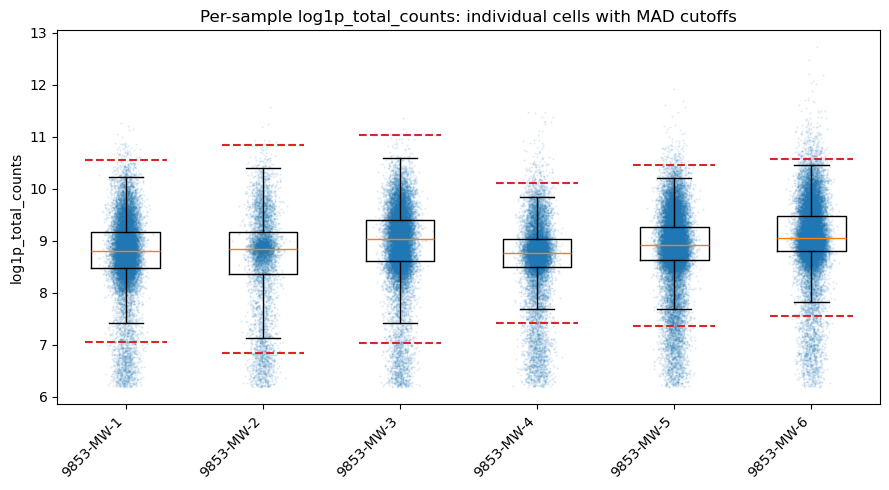

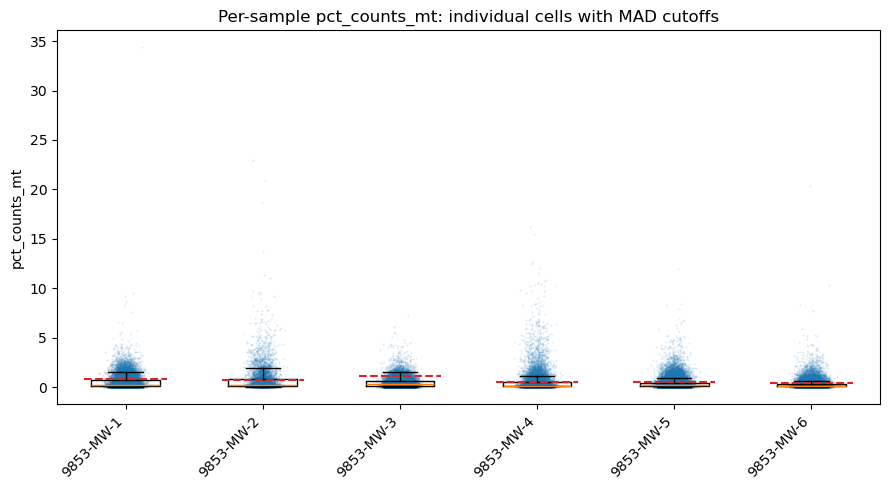

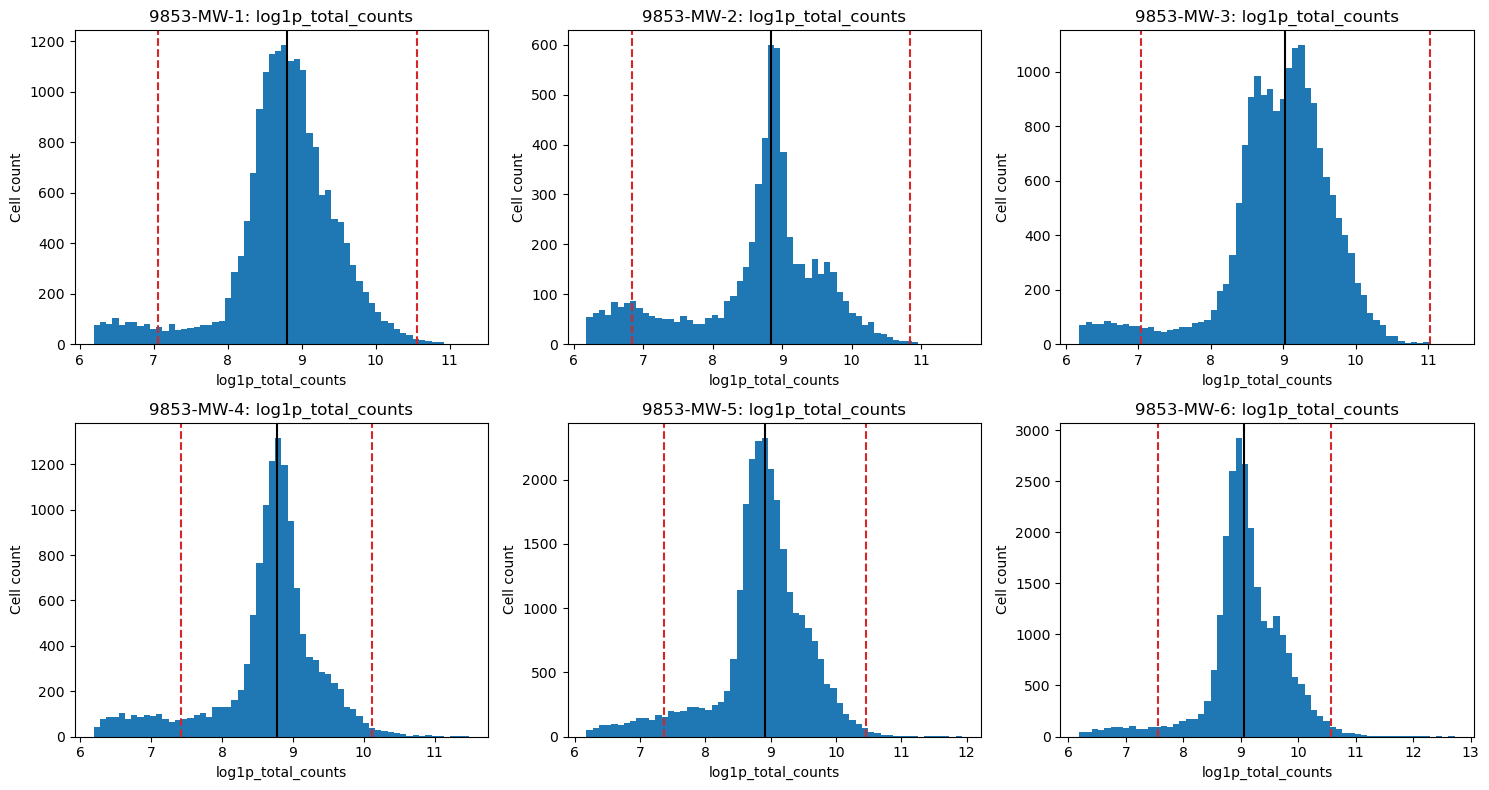

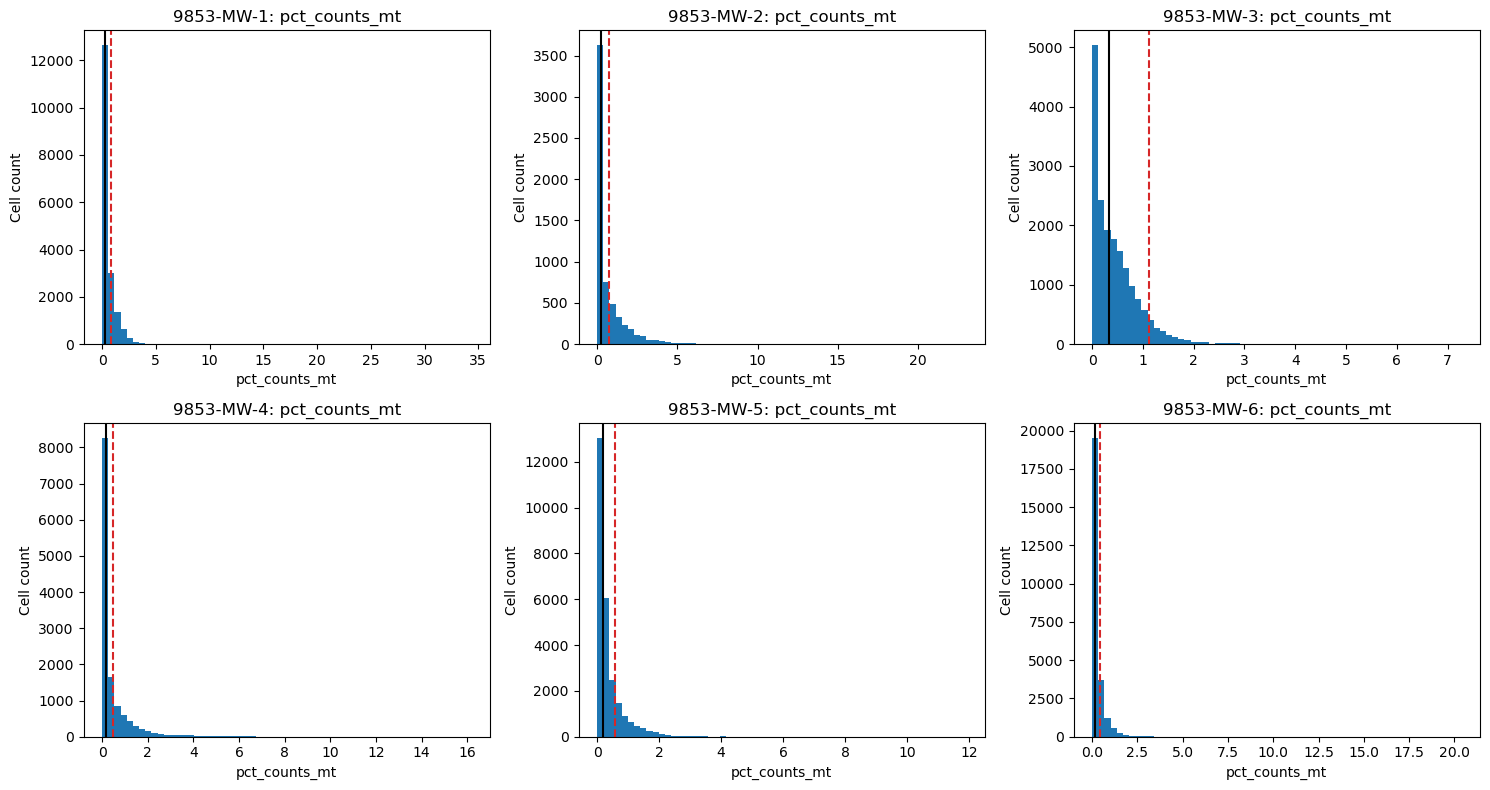

,run_sample_id,starting_n_cells,flagged_log1p_total_counts_n_cells,flagged_pct_counts_mt_n_cells,annotated_for_review_n_cells,annotated_for_review_pct
0,9853-MW-1,18047,880,3552,4049,22.435862
1,9853-MW-2,6060,524,1770,1974,32.574257
2,9853-MW-3,17928,724,1478,2025,11.295181
3,9853-MW-4,13047,1302,3371,3767,28.872538
4,9853-MW-5,26408,1484,5136,5818,22.031203
5,9853-MW-6,25530,1266,4582,5131,20.097924


In [9]:
@dataclass
class PerSampleMADQC:
    """Annotate and visualize per-sample QC flags for a list of AnnData objects.

    This class is intentionally annotation-only:
    - `calculate_qc_metrics()` adds numeric Scanpy QC metrics to `.obs`
    - `annotate_mad_qc()` adds this notebook's 0/1 QC flags to `.obs`
    - threshold metadata is stored in `.uns`
    - no cells are filtered, subsetted, removed, or changed in `.X`

    For the 0/1 flags created here, `1` means the cell is flagged by that
    criterion and `0` means it is not flagged by that criterion.
    """

    adata_names: Sequence[str]
    adata_list: Sequence[ad.AnnData]

    def calculate_qc_metrics(self, mito_prefix: str = "MT-", overwrite: bool = False):
        """Add Scanpy QC metric columns to each AnnData object's `.obs`.

        This step is separate from the 0/1 MAD annotations below.

        Scanpy adds numeric per-cell columns to `.obs`, including:
        - `total_counts`
        - `log1p_total_counts`
        - `pct_counts_mt`

        `mito_prefix="MT-"` is the human mitochondrial gene-name prefix,
        matching genes like `MT-ND1`, `MT-CO1`, and `MT-CYB`.

        `var["mt"]` is not a gene prefix. It is just the name of a boolean
        AnnData `.var` column created below. In that column, `True` means the
        gene name starts with the human mitochondrial prefix `MT-`.

        `qc_vars=["mt"]` tells Scanpy to use the `.var["mt"]` boolean column
        when calculating mitochondrial percentage columns such as
        `pct_counts_mt`.
        """
        required_obs_columns = {
            "total_counts",
            "log1p_total_counts",
            "pct_counts_mt",
        }

        for one_sample_adata in self.adata_list:
            missing_qc_columns = required_obs_columns.difference(one_sample_adata.obs.columns)
            if overwrite or missing_qc_columns:
                # Human mitochondrial genes usually start with "MT-".
                # Store that True/False gene annotation in .var["mt"].
                # Here, "mt" is only a column name, not the gene prefix.
                one_sample_adata.var["mt"] = one_sample_adata.var_names.str.startswith(mito_prefix)

                # Tell Scanpy to use .var["mt"] when computing mitochondrial QC metrics.
                # This creates .obs["pct_counts_mt"] among other numeric QC columns.
                sc.pp.calculate_qc_metrics(
                    one_sample_adata,
                    qc_vars=["mt"],
                    percent_top=None,
                    log1p=True,
                    inplace=True,
                )

        return list(self.adata_names), list(self.adata_list)

    def _sample_position(self, run_sample_id: str = None, sample_index: int = None) -> int:
        """Resolve either a run_sample_id or numeric list index to one position."""
        if run_sample_id is None and sample_index is None:
            raise ValueError("Provide run_sample_id or sample_index.")
        if run_sample_id is not None and sample_index is not None:
            raise ValueError("Provide only one of run_sample_id or sample_index.")

        if run_sample_id is not None:
            adata_names = list(self.adata_names)
            if run_sample_id not in adata_names:
                raise ValueError(f"Unknown run_sample_id: {run_sample_id}")
            return adata_names.index(run_sample_id)

        if sample_index < 0 or sample_index >= len(self.adata_list):
            raise IndexError(f"sample_index must be between 0 and {len(self.adata_list) - 1}.")
        return sample_index

    def metric_values(self, metric: str, run_sample_id: str = None, sample_index: int = None) -> np.ndarray:
        """Return finite values for one QC metric from one sample."""
        position = self._sample_position(run_sample_id=run_sample_id, sample_index=sample_index)
        one_sample_adata = self.adata_list[position]

        if metric not in one_sample_adata.obs.columns:
            raise KeyError(f"{metric!r} is not in .obs. Run calculate_qc_metrics() first.")

        values = one_sample_adata.obs[metric].to_numpy(dtype=float)
        return values[np.isfinite(values)]

    def mad_bounds(self, metric: str, run_sample_id: str = None, sample_index: int = None, n_mads: float = 5):
        """Return median +/- n_mads * MAD for one sample and one metric."""
        values = self.metric_values(metric=metric, run_sample_id=run_sample_id, sample_index=sample_index)
        median_value = float(np.median(values))
        mad_value = float(mad(values))
        lower_bound = median_value - n_mads * mad_value
        upper_bound = median_value + n_mads * mad_value

        return {
            "median": median_value,
            "mad": mad_value,
            "lower_bound": lower_bound,
            "upper_bound": upper_bound,
            "n_cells": int(values.size),
        }

    def mad_outlier_mask(self, one_sample_adata: ad.AnnData, metric: str, n_mads: float, upper_only: bool = False):
        """Return a boolean Series identifying MAD outliers for one metric."""
        if metric not in one_sample_adata.obs.columns:
            raise KeyError(f"{metric!r} is not in .obs. Run calculate_qc_metrics() first.")

        values = one_sample_adata.obs[metric].astype(float)
        median_value = float(np.median(values))
        mad_value = float(mad(values))
        lower_bound = median_value - n_mads * mad_value
        upper_bound = median_value + n_mads * mad_value

        if upper_only:
            return values > upper_bound
        return (values < lower_bound) | (values > upper_bound)

    def annotate_mad_qc(self):
        """Write 0/1 MAD QC annotations into each AnnData object's `.obs`.

        This method only annotates cells. It does not remove cells.

        Rules:
        - `log1p_total_counts`: 5 MADs, two-sided
        - `pct_counts_mt`: 3 MADs, upper-only

        Output columns added to `.obs`:
        - `qc_mad_flag_log1p_total_counts`
        - `qc_mad_flag_pct_counts_mt`

        In both columns, `1` means the cell is flagged by that criterion and
        `0` means it is not flagged by that criterion.
        """
        rules = [
            {
                "metric": "log1p_total_counts",
                "flag_column": "qc_mad_flag_log1p_total_counts",
                "n_mads": 5,
                "upper_only": False,
            },
            {
                "metric": "pct_counts_mt",
                "flag_column": "qc_mad_flag_pct_counts_mt",
                "n_mads": 3,
                "upper_only": True,
            },
        ]

        for run_sample_id, one_sample_adata in zip(self.adata_names, self.adata_list):
            threshold_records = []

            for rule in rules:
                metric = rule["metric"]
                flag_column = rule["flag_column"]
                n_mads = rule["n_mads"]
                upper_only = rule["upper_only"]

                mask = self.mad_outlier_mask(
                    one_sample_adata=one_sample_adata,
                    metric=metric,
                    n_mads=n_mads,
                    upper_only=upper_only,
                )
                one_sample_adata.obs[flag_column] = mask.astype("int8")

                bounds = self.mad_bounds(metric=metric, run_sample_id=run_sample_id, n_mads=n_mads)
                bounds.update(
                    {
                        "metric": metric,
                        "flag_column": flag_column,
                        "n_mads": n_mads,
                        "upper_only": upper_only,
                        "flag_meaning": "1 = flagged by this criterion; 0 = not flagged by this criterion",
                    }
                )
                threshold_records.append(bounds)

            one_sample_adata.uns["qc_mad_annotation_rules"] = threshold_records
            one_sample_adata.uns["qc_mad_annotation_note"] = (
                "Annotation only: 0/1 QC flags were added to .obs; no cells were filtered or removed."
            )

        return list(self.adata_names), list(self.adata_list)

    def annotate_manual_threshold(
        self,
        metric: str,
        threshold: float,
        direction: str = "above",
        column_name: str = None,
    ):
        """Annotate a user-defined threshold as a 0/1 `.obs` column.

        Use `direction='above'` for rules like pct_counts_mt > 25.
        Use `direction='below'` for rules like total_counts < 500.
        `1` means flagged by the manual rule; `0` means not flagged.
        """
        if direction not in {"above", "below"}:
            raise ValueError("direction must be 'above' or 'below'.")

        if column_name is None:
            operator_name = "gt" if direction == "above" else "lt"
            column_name = f"qc_manual_{metric}_{operator_name}_{threshold:g}"

        for one_sample_adata in self.adata_list:
            if metric not in one_sample_adata.obs.columns:
                raise KeyError(f"{metric!r} is not in .obs. Run calculate_qc_metrics() first.")

            values = one_sample_adata.obs[metric].astype(float)
            if direction == "above":
                mask = values > threshold
            else:
                mask = values < threshold
            one_sample_adata.obs[column_name] = mask.astype("int8")

            one_sample_adata.uns.setdefault("qc_manual_annotation_rules", []).append(
                {
                    "metric": metric,
                    "threshold": float(threshold),
                    "direction": direction,
                    "column_name": column_name,
                    "flag_meaning": "1 = flagged by this manual criterion; 0 = not flagged",
                    "note": "Annotation only: no cells were filtered or removed.",
                }
            )

        return list(self.adata_names), list(self.adata_list)

    def mad_bounds_table(self, metric: str = "log1p_total_counts", n_mads: float = 5, upper_only: bool = False) -> pd.DataFrame:
        """Return one MAD-threshold summary row per sample."""
        records = []

        for run_sample_id in self.adata_names:
            record = self.mad_bounds(metric=metric, run_sample_id=run_sample_id, n_mads=n_mads)
            record["run_sample_id"] = run_sample_id
            record["metric"] = metric
            record["n_mads"] = n_mads
            record["upper_only"] = upper_only
            records.append(record)

        return pd.DataFrame(records)[
            [
                "run_sample_id",
                "metric",
                "n_mads",
                "upper_only",
                "n_cells",
                "median",
                "mad",
                "lower_bound",
                "upper_bound",
            ]
        ]

    def qc_annotation_summary_table(self) -> pd.DataFrame:
        """Summarize 0/1 QC annotations per sample without filtering cells."""
        records = []

        for run_sample_id, one_sample_adata in zip(self.adata_names, self.adata_list):
            starting_n_cells = int(one_sample_adata.n_obs)
            total_count_flags = int(one_sample_adata.obs["qc_mad_flag_log1p_total_counts"].sum())
            mito_flags = int(one_sample_adata.obs["qc_mad_flag_pct_counts_mt"].sum())

            combined_review_mask = (
                one_sample_adata.obs["qc_mad_flag_log1p_total_counts"].astype(bool)
                | one_sample_adata.obs["qc_mad_flag_pct_counts_mt"].astype(bool)
            )
            annotated_for_review = int(combined_review_mask.sum())

            records.append(
                {
                    "run_sample_id": run_sample_id,
                    "starting_n_cells": starting_n_cells,
                    "flagged_log1p_total_counts_n_cells": total_count_flags,
                    "flagged_pct_counts_mt_n_cells": mito_flags,
                    "annotated_for_review_n_cells": annotated_for_review,
                    "annotated_for_review_pct": 100 * annotated_for_review / starting_n_cells,
                }
            )

        return pd.DataFrame(records)

    def print_annotation_report(self):
        """Print per-sample starting counts and 0/1 annotation counts."""
        summary_df = self.qc_annotation_summary_table()
        print("QC annotation report: no cells are filtered or removed in this step.")
        print("0/1 QC flags live in each sample AnnData object's .obs table; 1 means flagged.")

        for _, row in summary_df.iterrows():
            print(
                f"{row['run_sample_id']}: "
                f"starting_n_cells={int(row['starting_n_cells'])}, "
                f"annotated_for_review_n_cells={int(row['annotated_for_review_n_cells'])}, "
                f"annotated_for_review_pct={row['annotated_for_review_pct']:.2f}%"
            )

        return summary_df

    def plot_sample_distribution(
        self,
        metric: str = "log1p_total_counts",
        run_sample_id: str = None,
        sample_index: int = None,
        n_mads: float = 5,
        upper_only: bool = False,
        bins: int = 60,
        ax=None,
    ):
        """Plot one sample's metric distribution with MAD cutoff lines."""
        position = self._sample_position(run_sample_id=run_sample_id, sample_index=sample_index)
        resolved_run_sample_id = list(self.adata_names)[position]
        values = self.metric_values(metric=metric, sample_index=position)
        bounds = self.mad_bounds(metric=metric, sample_index=position, n_mads=n_mads)

        if ax is None:
            _, ax = plt.subplots(figsize=(6, 4))

        ax.hist(values, bins=bins)
        if not upper_only:
            ax.axvline(bounds["lower_bound"], color="tab:red", linestyle="--")
        ax.axvline(bounds["upper_bound"], color="tab:red", linestyle="--")
        ax.axvline(bounds["median"], color="black")
        ax.set_title(f"{resolved_run_sample_id}: {metric}")
        ax.set_xlabel(metric)
        ax.set_ylabel("Cell count")
        return ax

    def plot_all_distributions(
        self,
        metric: str = "log1p_total_counts",
        n_mads: float = 5,
        upper_only: bool = False,
        bins: int = 60,
    ):
        """Plot one MAD-threshold histogram panel per sample."""
        n_samples = len(self.adata_list)
        n_cols = min(3, n_samples)
        n_rows = int(np.ceil(n_samples / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)

        for sample_index, ax in enumerate(axes.flat):
            if sample_index < n_samples:
                self.plot_sample_distribution(
                    metric=metric,
                    sample_index=sample_index,
                    n_mads=n_mads,
                    upper_only=upper_only,
                    bins=bins,
                    ax=ax,
                )
            else:
                ax.axis("off")

        fig.tight_layout()
        return fig

    def plot_metric_boxplot(self, metric: str, n_mads: float = 5, upper_only: bool = False):
        """Compare one QC metric across samples with boxes plus one dot per cell."""
        values_by_sample = [self.metric_values(metric=metric, sample_index=i) for i in range(len(self.adata_list))]
        positions = np.arange(1, len(values_by_sample) + 1)
        fig, ax = plt.subplots(figsize=(max(8, 1.5 * len(values_by_sample)), 5))
        ax.boxplot(values_by_sample, positions=positions, showfliers=False)

        rng = np.random.default_rng(0)
        for position, run_sample_id, values in zip(positions, self.adata_names, values_by_sample):
            jitter = rng.normal(loc=0, scale=0.05, size=len(values))
            ax.scatter(
                np.full(len(values), position) + jitter,
                values,
                s=2,
                alpha=0.15,
                linewidths=0,
                color="tab:blue",
            )

            bounds = self.mad_bounds(metric=metric, run_sample_id=run_sample_id, n_mads=n_mads)
            ax.hlines(bounds["upper_bound"], position - 0.3, position + 0.3, colors="tab:red", linestyles="--")
            if not upper_only:
                ax.hlines(bounds["lower_bound"], position - 0.3, position + 0.3, colors="tab:red", linestyles="--")

        ax.set_xticks(positions)
        ax.set_xticklabels(self.adata_names, rotation=45, ha="right")
        ax.set_ylabel(metric)
        ax.set_title(f"Per-sample {metric}: individual cells with MAD cutoffs")
        fig.tight_layout()
        return fig


qc_runner = PerSampleMADQC(adata_names=adata_names, adata_list=adata_list)

# Step 1: Scanpy-created numeric QC metrics.
# These are stored in each sample's .obs, while mitochondrial gene labels are stored in .var['mt'].
adata_names, adata_list = qc_runner.calculate_qc_metrics()

# Step 2: Notebook-created 0/1 QC annotations.
# These are stored in each sample's .obs. 1 means flagged; 0 means not flagged.
# This does not filter or remove cells.
adata_names, adata_list = qc_runner.annotate_mad_qc()

# Per-sample starting counts and annotation counts.
# `annotated_for_review_n_cells` is computed from the two 0/1 flag columns; it is not stored as another .obs column.
qc_annotation_summary_df = qc_runner.print_annotation_report()
display(qc_annotation_summary_df)

print("0/1 QC columns stored in each AnnData .obs:")
print([column for column in adata_list[0].obs.columns if column.startswith("qc_")])

qc_total_counts_mad_summary_df = qc_runner.mad_bounds_table(
    metric="log1p_total_counts",
    n_mads=5,
    upper_only=False,
)
display(qc_total_counts_mad_summary_df)

qc_mito_mad_summary_df = qc_runner.mad_bounds_table(
    metric="pct_counts_mt",
    n_mads=3,
    upper_only=True,
)
display(qc_mito_mad_summary_df)

# Overall per-sample distribution views.
qc_runner.plot_metric_boxplot(metric="log1p_total_counts", n_mads=5, upper_only=False)
plt.show()

qc_runner.plot_metric_boxplot(metric="pct_counts_mt", n_mads=3, upper_only=True)
plt.show()

# Detailed per-sample histograms, useful after the boxplots.
qc_runner.plot_all_distributions(metric="log1p_total_counts", n_mads=5, upper_only=False)
plt.show()

qc_runner.plot_all_distributions(metric="pct_counts_mt", n_mads=3, upper_only=True)
plt.show()

# Optional manual annotation example. Uncomment to add a fixed mitochondrial threshold flag.
# adata_names, adata_list = qc_runner.annotate_manual_threshold(
#     metric="pct_counts_mt",
#     threshold=25,
#     direction="above",
#     column_name="qc_manual_pct_counts_mt_gt_25",
# )


# total of cell after filer is 
qc_runner.qc_annotation_summary_table()


In [11]:
# QC-filtered branch (in-memory): keep original adata_list unchanged.
# This cell does only filtering + concatenation so it is fast to rerun.

print("[1/3] Starting per-sample QC filtering...")

# Build run_sample_id -> biological_label map from sample metadata, if available.
biological_label_map = {}
try:
    sample_map_df = pd.read_csv(anndata_builder.sample_map_tsv, sep="\t")
    if {"run_sample_id", "biological_label"}.issubset(sample_map_df.columns):
        biological_label_map = (
            sample_map_df[["run_sample_id", "biological_label"]]
            .dropna(subset=["run_sample_id"])
            .drop_duplicates(subset=["run_sample_id"])
            .assign(run_sample_id=lambda df: df["run_sample_id"].astype(str))
            .set_index("run_sample_id")["biological_label"]
            .to_dict()
        )
except Exception as exc:
    print(f"Warning: could not load biological_label map from sample map TSV: {exc}")

# 1) Per-sample QC filtering without overwriting adata_list.
adata_list_qc_filtered = []
qc_filter_records = []

for run_sample_id, one_sample_adata in zip(adata_names, adata_list):
    required_flags = ["qc_mad_flag_log1p_total_counts", "qc_mad_flag_pct_counts_mt"]
    missing_flags = [column for column in required_flags if column not in one_sample_adata.obs.columns]
    if missing_flags:
        raise KeyError(
            f"Missing required QC flag columns in sample {run_sample_id}: {missing_flags}. "
            "Run qc_runner.calculate_qc_metrics() and qc_runner.annotate_mad_qc() first."
        )

    keep_mask = (
        (one_sample_adata.obs["qc_mad_flag_log1p_total_counts"].astype(int) == 0)
        & (one_sample_adata.obs["qc_mad_flag_pct_counts_mt"].astype(int) == 0)
    )

    flagged_n_cells = int((~keep_mask).sum())
    retained_n_cells = int(keep_mask.sum())
    starting_n_cells = int(one_sample_adata.n_obs)
    retained_pct = 100.0 * retained_n_cells / starting_n_cells if starting_n_cells > 0 else np.nan

    filtered_sample = one_sample_adata[keep_mask].copy()

    # Preserve required metadata columns in .obs.
    filtered_sample.obs["run_sample_id"] = filtered_sample.obs["run_sample_id"].astype("string")
    filtered_sample.obs["DIV"] = filtered_sample.obs["DIV"].astype("string")

    if "biological_label" not in filtered_sample.obs.columns:
        if str(run_sample_id) in biological_label_map:
            filtered_sample.obs["biological_label"] = str(biological_label_map[str(run_sample_id)])
        elif "cell_line" in filtered_sample.obs.columns:
            # Fallback if biological_label is unavailable in source metadata.
            filtered_sample.obs["biological_label"] = filtered_sample.obs["cell_line"].astype("string")
        else:
            filtered_sample.obs["biological_label"] = "unknown"
    filtered_sample.obs["biological_label"] = filtered_sample.obs["biological_label"].astype("string")

    adata_list_qc_filtered.append(filtered_sample)
    qc_filter_records.append(
        {
            "run_sample_id": str(run_sample_id),
            "starting_n_cells": starting_n_cells,
            "flagged_n_cells": flagged_n_cells,
            "retained_n_cells": retained_n_cells,
            "retained_pct": retained_pct,
        }
    )

qc_filter_summary_df = pd.DataFrame(qc_filter_records).sort_values("run_sample_id").reset_index(drop=True)
print("[1/3] Per-sample QC filtering summary (annotation-based filtering):")
display(qc_filter_summary_df)

print("[2/3] Concatenating filtered samples...")
adata_div30_qc_filtered = ad.concat(
    {str(run_sample_id): one_sample_adata for run_sample_id, one_sample_adata in zip(adata_names, adata_list_qc_filtered)},
    axis=0,
    join="outer",
    merge="same",
    fill_value=0,
    index_unique=None,
    label="batch",
)

# Keep explicit metadata columns and ensure stable dtypes.
if "batch" in adata_div30_qc_filtered.obs.columns:
    adata_div30_qc_filtered.obs["run_sample_id"] = adata_div30_qc_filtered.obs["batch"].astype("string")

for required_obs_col in ["run_sample_id", "DIV", "biological_label"]:
    if required_obs_col not in adata_div30_qc_filtered.obs.columns:
        raise KeyError(f"Required .obs column missing after concat: {required_obs_col}")
    adata_div30_qc_filtered.obs[required_obs_col] = adata_div30_qc_filtered.obs[required_obs_col].astype("string")

print("[3/3] Filtered concatenated object ready")
print("Filtered concatenated object:", adata_div30_qc_filtered.shape)
print("Unique run_sample_id:", adata_div30_qc_filtered.obs["run_sample_id"].nunique())
print("Unique biological_label:", adata_div30_qc_filtered.obs["biological_label"].nunique())
print("Next: run the preprocessing cell.")

[1/3] Starting per-sample QC filtering...
[1/3] Per-sample QC filtering summary (annotation-based filtering):


,run_sample_id,starting_n_cells,flagged_n_cells,retained_n_cells,retained_pct
0,9853-MW-1,18047,4049,13998,77.564138
1,9853-MW-2,6060,1974,4086,67.425743
2,9853-MW-3,17928,2025,15903,88.704819
3,9853-MW-4,13047,3767,9280,71.127462
4,9853-MW-5,26408,5818,20590,77.968797
5,9853-MW-6,25530,5131,20399,79.902076


[2/3] Concatenating filtered samples...
[3/3] Filtered concatenated object ready
Filtered concatenated object: (84256, 18082)
Unique run_sample_id: 6
Unique biological_label: 6
Next: run the preprocessing cell.


In [12]:
# Step A: Uncorrected preprocessing for exploratory batch-effect diagnosis only.
# This step does not run integration, clustering, DE, pseudotime, or trajectory inference.

import time
import warnings

print("[Preprocess] Starting normalize/log/HVG/PCA...")
t0 = time.perf_counter()

# Optional: silence noisy notebook progress-bar warning when ipywidgets is unavailable.
try:
    from tqdm import TqdmWarning
    warnings.filterwarnings("ignore", category=TqdmWarning)
except Exception:
    pass

sc.pp.normalize_total(adata_div30_qc_filtered, target_sum=1e4)
print("[Preprocess] normalize_total done")

sc.pp.log1p(adata_div30_qc_filtered)
print("[Preprocess] log1p done")

sc.pp.highly_variable_genes(
    adata_div30_qc_filtered,
    n_top_genes=2000,
    batch_key="run_sample_id",
    flavor="seurat",
)
print("[Preprocess] highly_variable_genes done")

# Use mask_var to avoid deprecated use_highly_variable argument.
sc.tl.pca(
    adata_div30_qc_filtered,
    mask_var="highly_variable",
    svd_solver="arpack",
)
print("[Preprocess] PCA done")

print(f"[Preprocess] Completed in {time.perf_counter() - t0:.1f} seconds")

[Preprocess] Starting normalize/log/HVG/PCA...
[Preprocess] normalize_total done
[Preprocess] log1p done
[Preprocess] highly_variable_genes done
[Preprocess] PCA done
[Preprocess] Completed in 37.1 seconds


In [13]:
# Step B: Graph + UMAP embedding.
# This can be the slowest part; progress prints are included.

import time

print("[Embedding] Starting neighbors + UMAP...")
t0 = time.perf_counter()

sc.pp.neighbors(adata_div30_qc_filtered)
print("[Embedding] neighbors done")

sc.tl.umap(adata_div30_qc_filtered)
print("[Embedding] UMAP done")

print(f"[Embedding] Completed in {time.perf_counter() - t0:.1f} seconds")
print("Next: run the visualization cells.")

[Embedding] Starting neighbors + UMAP...
[Embedding] neighbors done
[Embedding] UMAP done
[Embedding] Completed in 121.7 seconds
Next: run the visualization cells.


[Plots C] PCA by run_sample_id


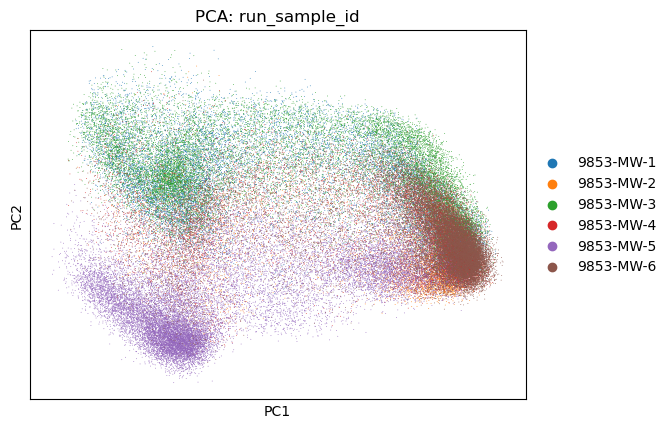

[Plots C] UMAP by run_sample_id


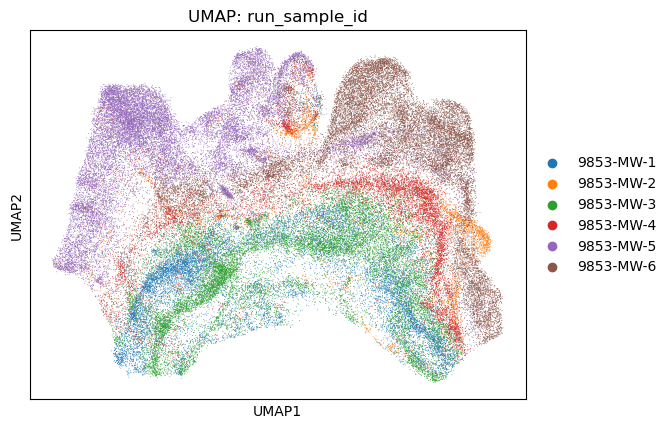

[Plots C] UMAP by QC metrics


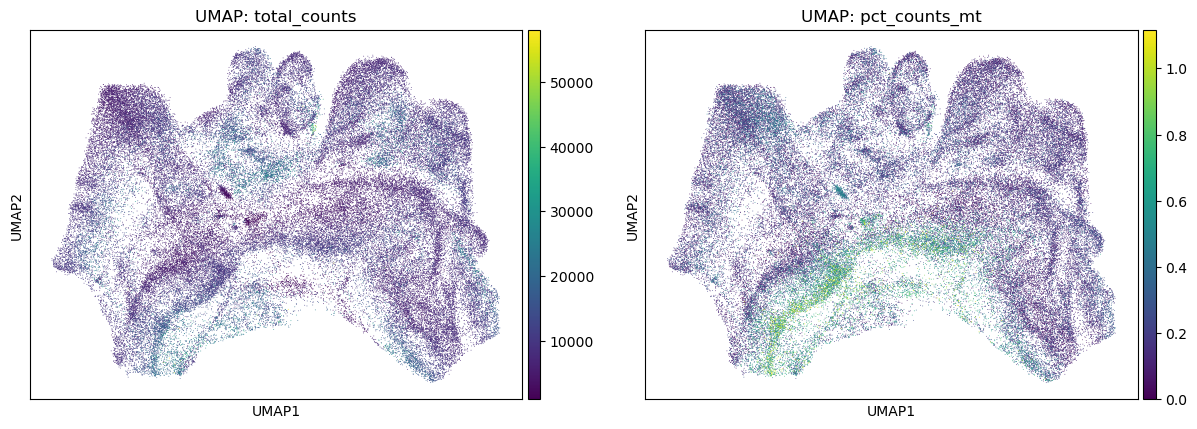

[Plots C] HVG summary


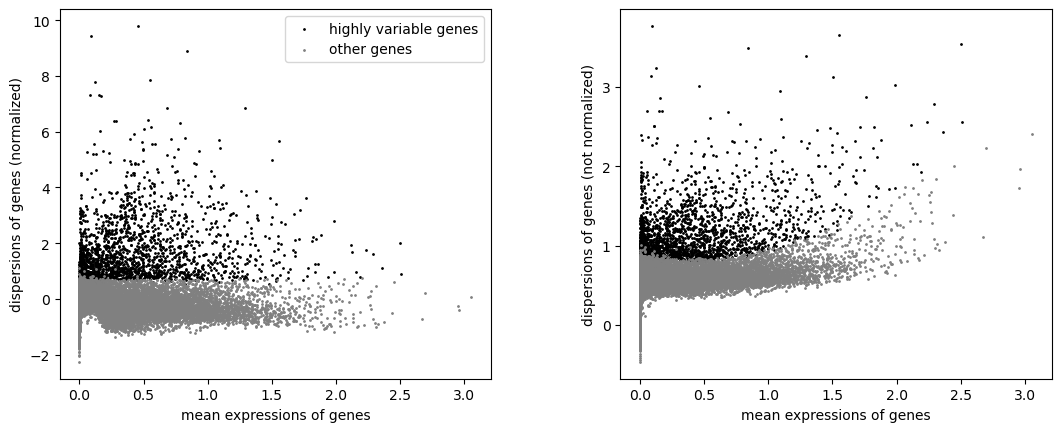

[Plots C] Violin QC by run_sample_id


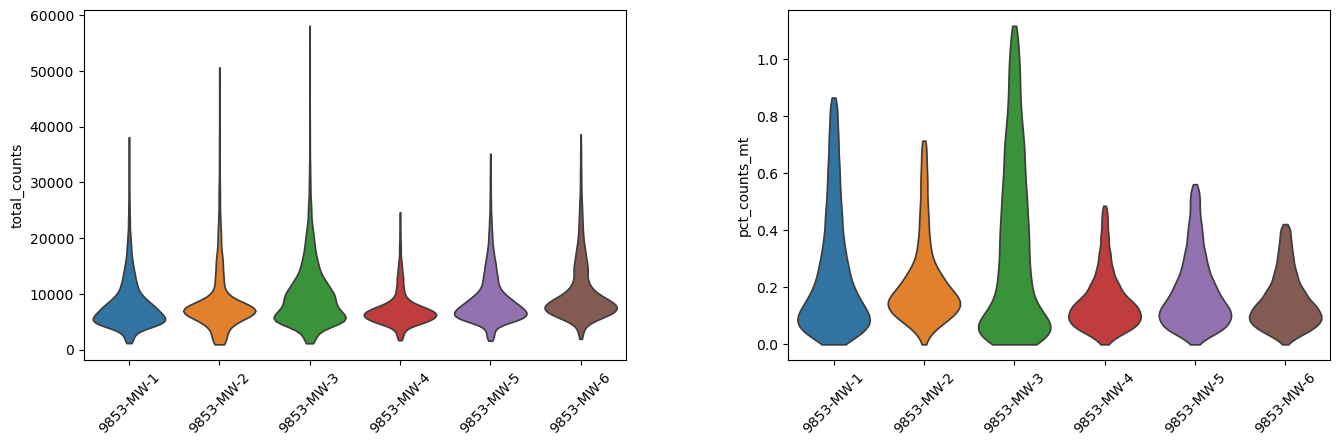

[Plots C] QC scatter


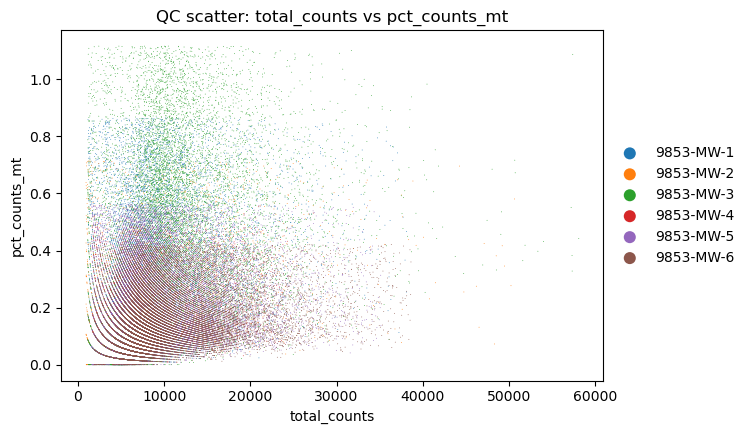

In [14]:
# Step C: Core diagnostic plots using native Scanpy functions.

print("[Plots C] PCA by run_sample_id")
sc.pl.pca(adata_div30_qc_filtered, color=["run_sample_id"], title="PCA: run_sample_id")

print("[Plots C] UMAP by run_sample_id")
sc.pl.umap(adata_div30_qc_filtered, color=["run_sample_id"], title="UMAP: run_sample_id")

print("[Plots C] UMAP by QC metrics")
sc.pl.umap(
    adata_div30_qc_filtered,
    color=["total_counts", "pct_counts_mt"],
    color_map="viridis",
    title=["UMAP: total_counts", "UMAP: pct_counts_mt"],
)

print("[Plots C] HVG summary")
sc.pl.highly_variable_genes(adata_div30_qc_filtered)

print("[Plots C] Violin QC by run_sample_id")
sc.pl.violin(
    adata_div30_qc_filtered,
    keys=["total_counts", "pct_counts_mt"],
    groupby="run_sample_id",
    rotation=45,
    stripplot=False,
)

print("[Plots C] QC scatter")
sc.pl.scatter(
    adata_div30_qc_filtered,
    x="total_counts",
    y="pct_counts_mt",
    color="run_sample_id",
    title="QC scatter: total_counts vs pct_counts_mt",
)

[Plots D] Markers present: ['SOX2', 'VIM', 'MKI67', 'EOMES', 'DCX', 'GAD1', 'GAD2', 'DLX1', 'DLX2']


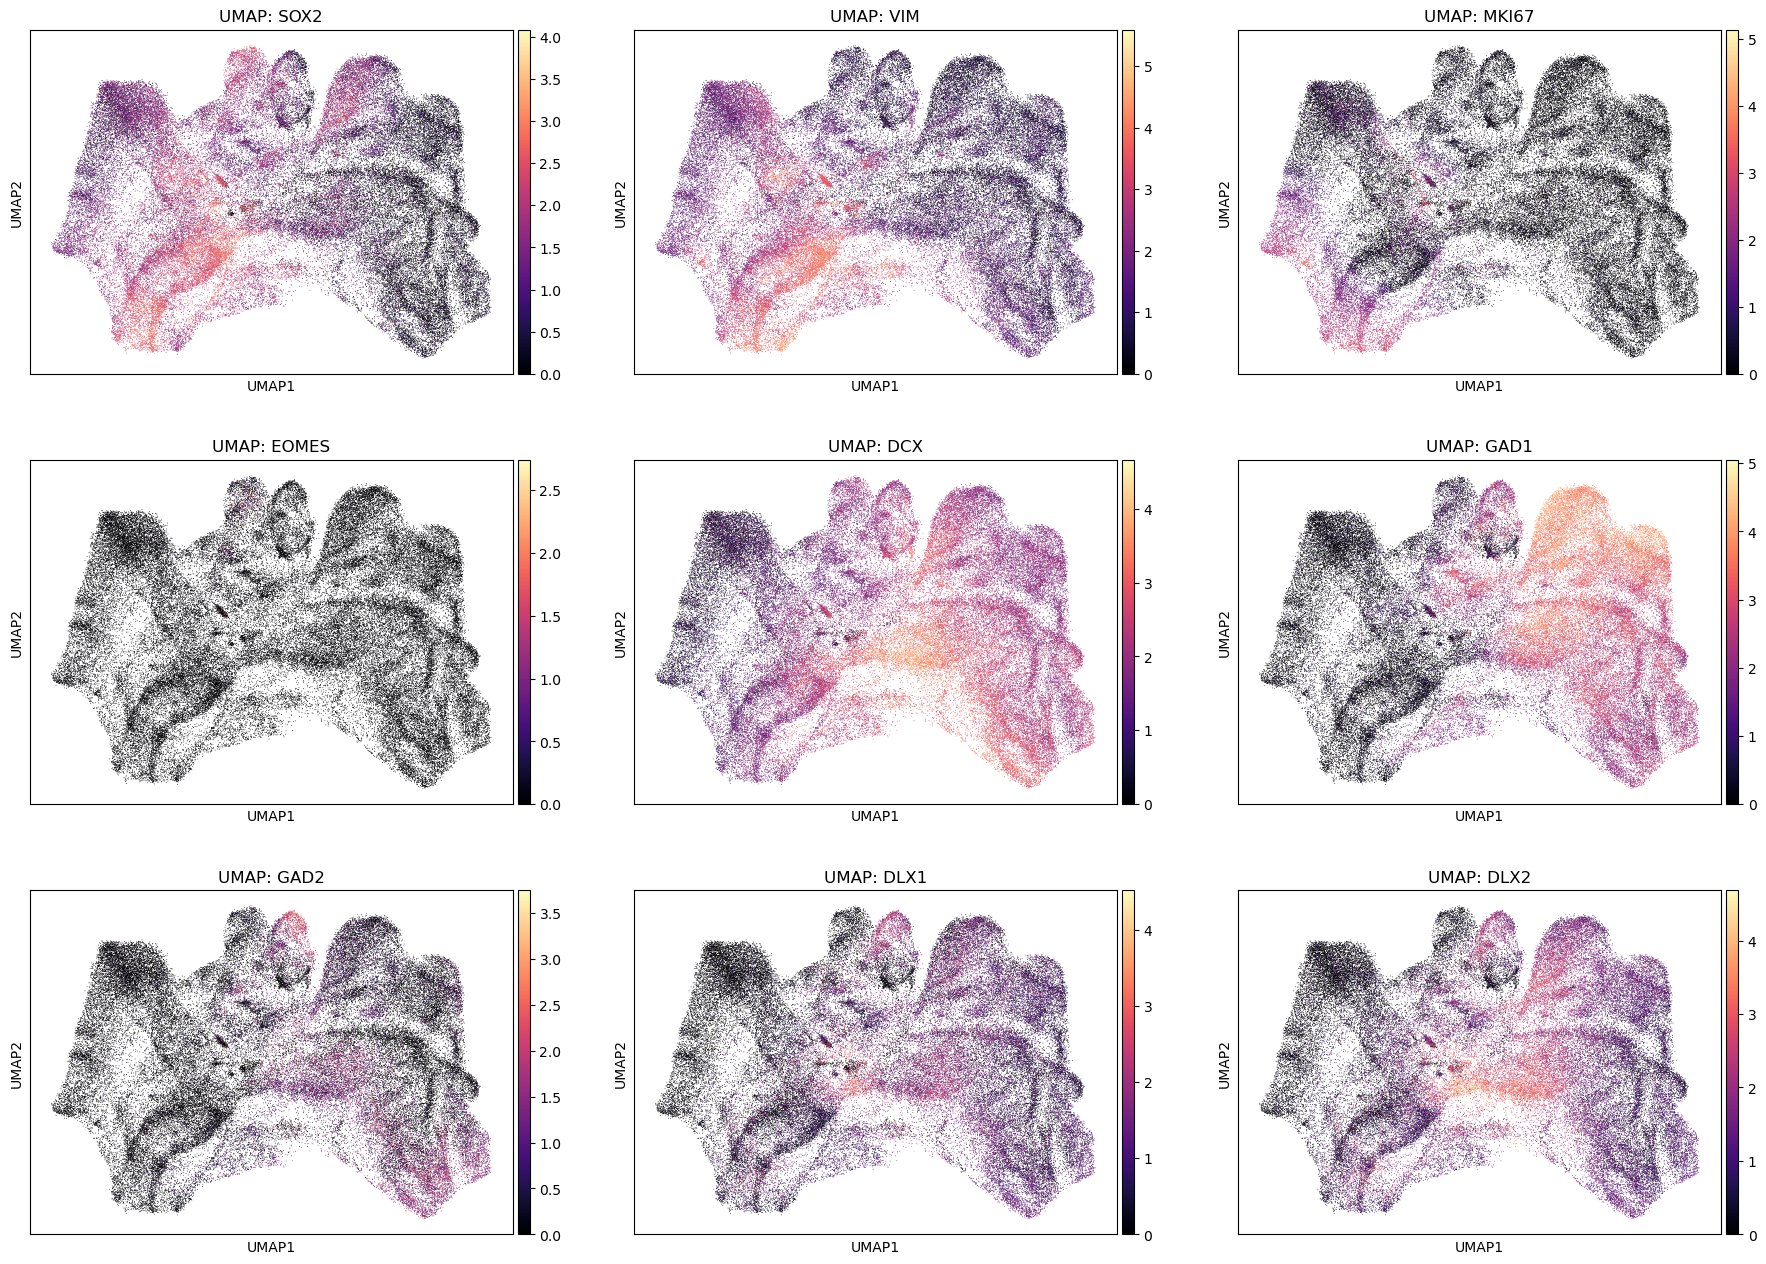

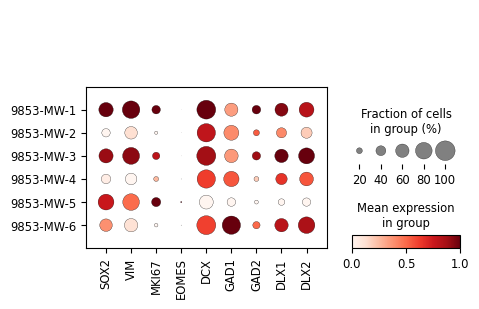

Exploratory uncorrected object is ready: adata_div30_qc_filtered


In [15]:
# Step D: Developmental marker diagnostics (if genes are present).

developmental_markers = ["SOX2", "VIM", "MKI67", "EOMES", "DCX", "GAD1", "GAD2", "DLX1", "DLX2"]
markers_present = [gene for gene in developmental_markers if gene in adata_div30_qc_filtered.var_names]
markers_missing = [gene for gene in developmental_markers if gene not in adata_div30_qc_filtered.var_names]

print("[Plots D] Markers present:", markers_present)
if markers_missing:
    print("[Plots D] Requested markers not found:", markers_missing)

if markers_present:
    sc.pl.umap(
        adata_div30_qc_filtered,
        color=markers_present,
        color_map="magma",
        ncols=3,
        title=[f"UMAP: {gene}" for gene in markers_present],
    )

    sc.pl.dotplot(
        adata_div30_qc_filtered,
        var_names=markers_present,
        groupby="run_sample_id",
        standard_scale="var",
    )

print("Exploratory uncorrected object is ready: adata_div30_qc_filtered")

In [16]:
pip install harmonypy

Note: you may need to restart the kernel to use updated packages.


In [18]:
# Step E: Light sample-level batch correction with Harmony on PCA space.
# Keep original expression matrix workflow intact by operating on a copy.

import scanpy.external as sce
import time

print("[Harmony 1/5] Creating working copy from adata_div30_qc_filtered...")
adata_div30_harmony = adata_div30_qc_filtered.copy()

print("[Harmony 2/5] Recomputing HVGs with batch_key=run_sample_id...")
t0 = time.perf_counter()
sc.pp.highly_variable_genes(
    adata_div30_harmony,
    n_top_genes=2000,
    batch_key="run_sample_id",
    flavor="seurat",
)
print(f"[Harmony] HVG complete in {time.perf_counter() - t0:.1f} seconds")

print("[Harmony 3/5] Scaling and PCA...")
t0 = time.perf_counter()
sc.pp.scale(adata_div30_harmony, max_value=10)
sc.tl.pca(
    adata_div30_harmony,
    mask_var="highly_variable",
    svd_solver="arpack",
)
print(f"[Harmony] Scale+PCA complete in {time.perf_counter() - t0:.1f} seconds")

print("[Harmony 4/5] Running Harmony integration with run_sample_id...")
t0 = time.perf_counter()
sce.pp.harmony_integrate(
    adata_div30_harmony,
    key="run_sample_id",
    basis="X_pca",
    adjusted_basis="X_pca_harmony",
)
print(f"[Harmony] Integration complete in {time.perf_counter() - t0:.1f} seconds")

print("[Harmony 5/5] Building Harmony neighbors + UMAP...")
t0 = time.perf_counter()
sc.pp.neighbors(adata_div30_harmony, use_rep="X_pca_harmony", key_added="harmony")
sc.tl.umap(adata_div30_harmony, neighbors_key="harmony")
print(f"[Harmony] Neighbors+UMAP complete in {time.perf_counter() - t0:.1f} seconds")

# Required output: save Harmony embedding on the main uncorrected object.
adata_div30_qc_filtered.obsm["X_pca_harmony"] = adata_div30_harmony.obsm["X_pca_harmony"].copy()

# Optional convenience copies for side-by-side downstream plotting/comparison.
adata_div30_qc_filtered.obsm["X_umap_harmony"] = adata_div30_harmony.obsm["X_umap"].copy()
if "harmony" in adata_div30_harmony.uns:
    adata_div30_qc_filtered.uns["harmony"] = adata_div30_harmony.uns["harmony"]
if "harmony_connectivities" in adata_div30_harmony.obsp:
    adata_div30_qc_filtered.obsp["harmony_connectivities"] = adata_div30_harmony.obsp["harmony_connectivities"].copy()
if "harmony_distances" in adata_div30_harmony.obsp:
    adata_div30_qc_filtered.obsp["harmony_distances"] = adata_div30_harmony.obsp["harmony_distances"].copy()

print("Harmony representations saved:")
print(" - adata_div30_qc_filtered.obsm['X_pca_harmony']")
print(" - adata_div30_harmony for Harmony-space analysis")

[Harmony 1/5] Creating working copy from adata_div30_qc_filtered...
[Harmony 2/5] Recomputing HVGs with batch_key=run_sample_id...
[Harmony] HVG complete in 18.1 seconds
[Harmony 3/5] Scaling and PCA...


/home/elcrespo/miniconda3/envs/mge-organoid-python/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)
2026-05-25 17:16:35,114 - harmonypy - INFO - Running Harmony
2026-05-25 17:16:35,115 - harmonypy - INFO -   Parameters:
2026-05-25 17:16:35,115 - harmonypy - INFO -     max_iter_harmony: 10
2026-05-25 17:16:35,115 - harmonypy - INFO -     max_iter_kmeans: 4
2026-05-25 17:16:35,116 - harmonypy - INFO -     epsilon_cluster: 0.001
2026-05-25 17:16:35,116 - harmonypy - INFO -     epsilon_harmony: 0.01
2026-05-25 17:16:35,116 - harmonypy - INFO -     nclust: 100
2026-05-25 17:16:35,116 - harmonypy - INFO -     block_size: 0.05
2026-05-25 17:16:35,119 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
2026-05-25 17:16:35,119 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2.]
2026-05-25 17:16:35,120 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-05-25 17:16:35,120 - harmonypy - INFO

[Harmony] Scale+PCA complete in 30.6 seconds
[Harmony 4/5] Running Harmony integration with run_sample_id...


2026-05-25 17:16:35,267 - harmonypy - INFO - Computing initial centroids...
2026-05-25 17:16:38,147 - harmonypy - INFO - Initialization complete.
2026-05-25 17:16:38,148 - harmonypy - INFO - Iteration 1 of 10
2026-05-25 17:16:40,843 - harmonypy - INFO - Iteration 2 of 10
2026-05-25 17:16:43,687 - harmonypy - INFO - Iteration 3 of 10
2026-05-25 17:16:46,536 - harmonypy - INFO - Iteration 4 of 10
2026-05-25 17:16:49,381 - harmonypy - INFO - Iteration 5 of 10
2026-05-25 17:16:52,232 - harmonypy - INFO - Iteration 6 of 10
2026-05-25 17:16:55,082 - harmonypy - INFO - Converged after 6 iterations


ValueError: Value passed for key 'X_pca_harmony' is of incorrect shape. Values of obsm must match dimensions ('obs',) of parent. Value had shape (50,) while it should have had (84256,).